# EDA

In [1]:
import os, sys
from datetime import datetime, timedelta
from collections import Counter

import numpy as np
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

data_path = "../kgdata/edges_v3.tsv"
tmp_dir = "../tmp/"
output_dir = "../output/"

if not os.path.isdir(tmp_dir):
    os.mkdir(tmp_dir)

if not os.path.isdir(output_dir):
    os.mkdir(output_dir)

graph_cache = tmp_dir + "wikidata.sqlite3"

df = pd.read_csv(data_path, sep='\t')

In [16]:
zones = ['Zone_204', 'Zone_196', 'Zone_222', 'Zone_207']
locations = []

for zone in zones:
    location = df[(df["node1"] == zone) & (df["label"] == "ZoneName")].node2.values[0]
    locations.append(location)

print(locations)

['Overlapping claim Taiwan: Taiwan / China', 'Israeli Exclusive Economic Zone', 'Japanese Exclusive Economic Zone', 'Chinese Exclusive Economic Zone']


In [21]:
df[df["label"] == "ZoneGeometry"]

,node1,label,node2,edge_id
356762,Zone_0,ZoneGeometry,Geom_0,Zone4


In [30]:
vessels = df[(df["label"] == "type") & (df["node2"] == "VesselIdentity")].node1.values

In [38]:
vessel2flag = {}

for vessel in vessels:
    vessel2flag[vessel] = df[(df["node1"] == vessel) &
                             (df["label"] == "Flag")].node2.values[0]

{'VesselIdentity_0': 'CHN', 'VesselIdentity_1': 'CHN', 'VesselIdentity_2': 'CHN', 'VesselIdentity_3': 'CHN', 'VesselIdentity_4': 'TWN', 'VesselIdentity_5': 'TWN', 'VesselIdentity_6': 'TWN', 'VesselIdentity_7': 'TWN', 'VesselIdentity_8': 'TWN', 'VesselIdentity_9': 'TWN', 'VesselIdentity_10': 'TWN', 'VesselIdentity_11': 'TWN', 'VesselIdentity_12': nan, 'VesselIdentity_13': 'CHN', 'VesselIdentity_14': nan, 'VesselIdentity_15': nan, 'VesselIdentity_16': 'CHN'}


In [65]:
def vessel2type(vessel: str):
    vt = df[(df["node1"] == vessel) &
            (df["label"] == "VesselTypeId")].node2.values[0]
    return df[(df["node1"] == vt) & (df["label"] == "TypeName")].node2.values[0]

'Passenger'

In [85]:
def vessel2event(vessel: str):
    return df[(df["label"] == "HasParticipant") &
              (df["node2"] == vessel)].node1.to_list()

def event2latlon(event: str):
    e_type = df[(df["node1"] == event) & (df["label"] == "EventType")].node2.values[0]
    zone = df[(df["node1"] == event) & (df["label"] == "Location")].node2.values[0]
    geometry = df[(df["node1"] == event) & (df["label"] == "EventGeometry")].node2.values[0]
    e_lat = float(df[(df["node1"] == geometry) & (df["label"] == "CentroidLat")].node2.values[0])
    e_lon = float(df[(df["node1"] == geometry) & (df["label"] == "CentroidLon")].node2.values[0])
    
    return (e_type, zone, e_lat, e_lon)

In [86]:
event_mmap = {
    "loitering": "o",
    "port_visit": "s",
    "fishing": "^"
}

zone_cmap = {
    "Zone_204": "red",
    "Zone_196": "blue",
    "Zone_222": "green",
    "Zone_207": "yellow"
}

def vessel_event_plot(vessel: str):
    events = vessel2event(vessel)
    events_info = list(map(lambda x: event2latlon(x), events))

    types = np.array([x[0] for x in events_info])
    zones = np.array([x[1] for x in events_info])
    lats = np.array([x[2] for x in events_info])
    lons = np.array([x[3] for x in events_info])

    lat_min, lat_max = lats.min() - 0.01, lats.max() + 0.01
    lon_min, lon_max = lons.min() - 0.01, lons.max() + 0.01

    fix, ax = plt.subplots(figsize=(10, 6))
    world_map = Basemap(projection="mill",
                        lon_0=0,
                        llcrnrlat=lat_min,
                        urcrnrlat=lat_max,
                        llcrnrlon=lon_min,
                        urcrnrlon=lon_max,
                        resolution='i',
                        ax=ax)
    world_map.drawcoastlines()
    world_map.drawmapboundary(fill_color="lightblue")
    world_map.fillcontinents(color="lightgray", lake_color="lightblue")

    x, y = world_map(lons, lats)

    title = f"{vessel2type(vessel)}:{vessel2flag[vessel]}"

    for event, marker in event_mmap.items():
        for zone, color in zone_cmap.items():
            idx = (types == event) & (zones == zone)
            world_map.scatter(
                x[idx], y[idx], marker=marker,
                color=color, s=50, edgecolors="black",
                label=f"{event}-{zone}"
            )

    plt.title(title)
    plt.show()

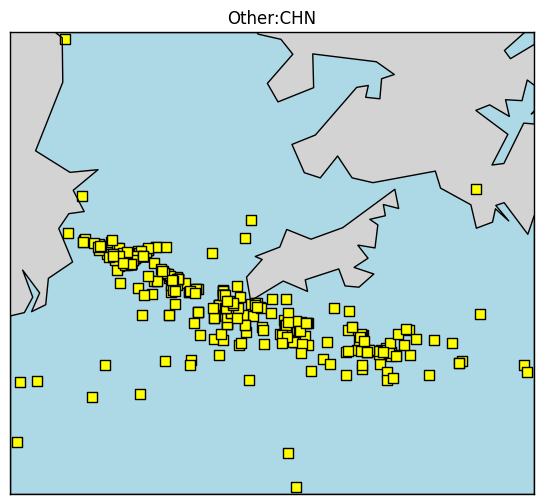

In [87]:
vessel_event_plot(vessels[0])

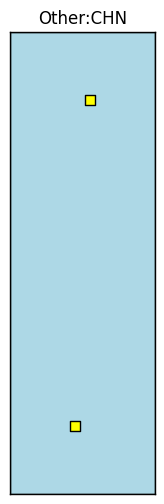

In [88]:
vessel_event_plot(vessels[1])

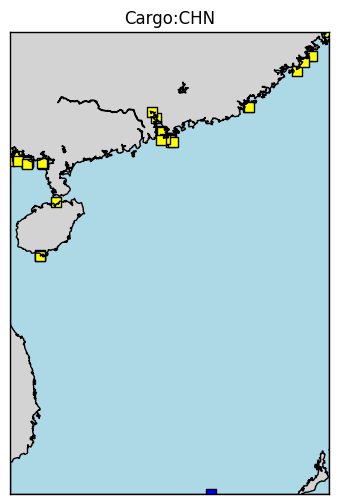

In [89]:
vessel_event_plot(vessels[2])

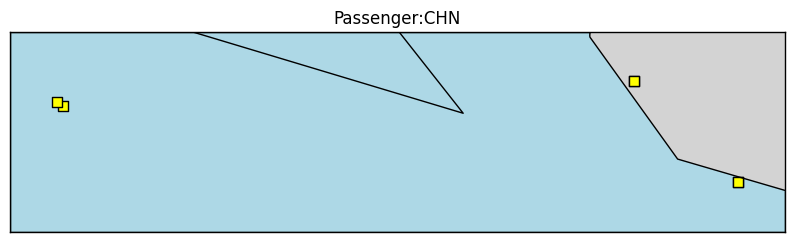

In [90]:
vessel_event_plot(vessels[3])

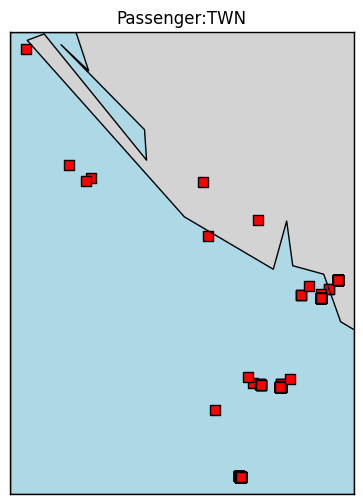

In [91]:
vessel_event_plot(vessels[4])

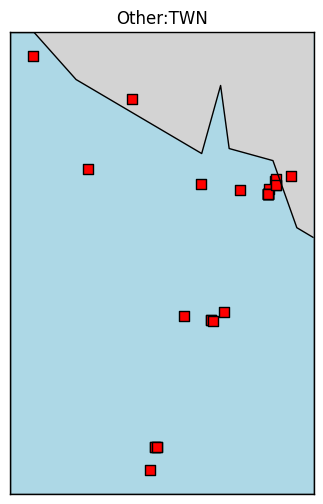

In [92]:
vessel_event_plot(vessels[5])

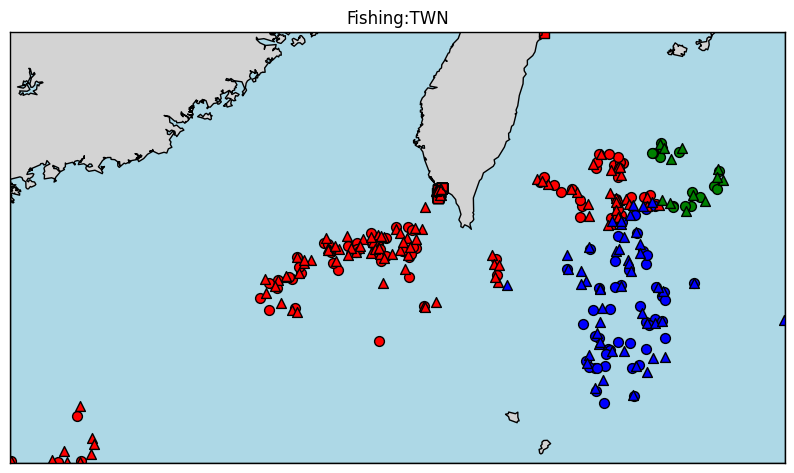

In [93]:
vessel_event_plot(vessels[6])

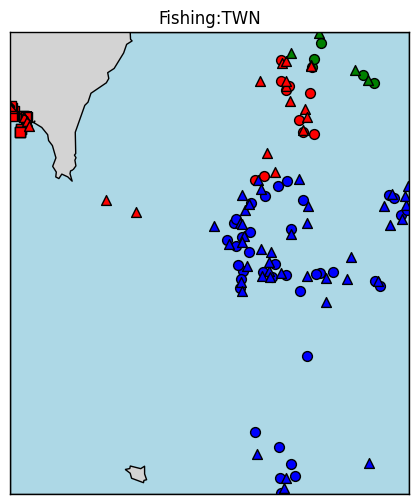

In [94]:
vessel_event_plot(vessels[7])

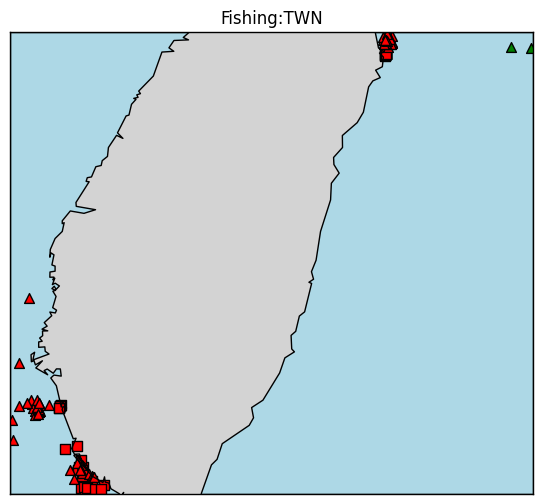

In [95]:
vessel_event_plot(vessels[8])

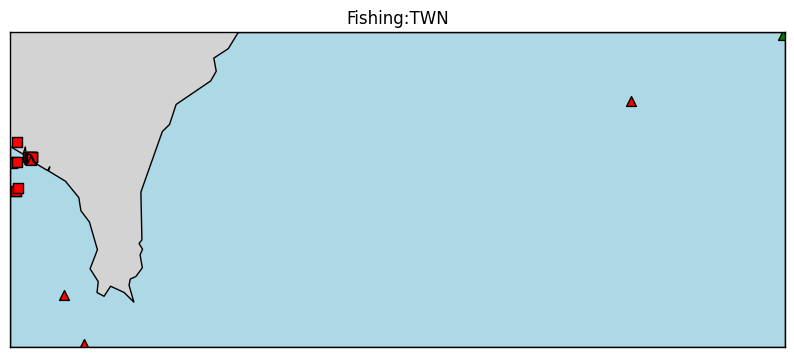

In [96]:
vessel_event_plot(vessels[9])

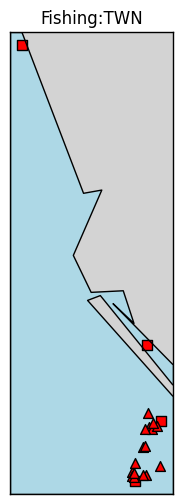

In [97]:
vessel_event_plot(vessels[10])

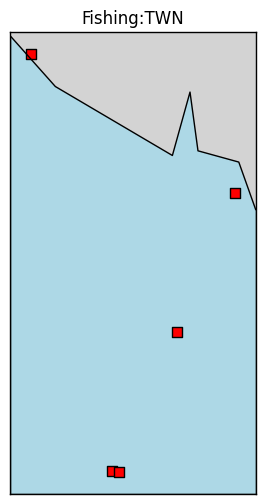

In [98]:
vessel_event_plot(vessels[11])

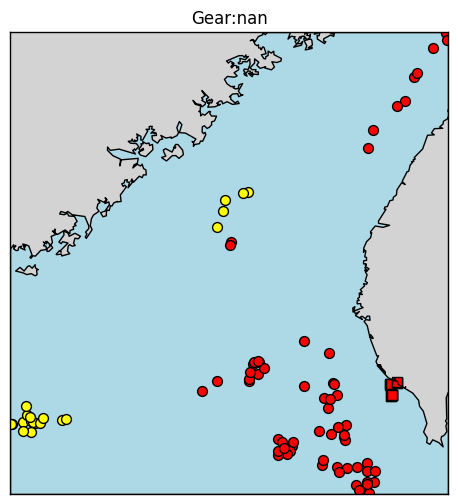

In [99]:
vessel_event_plot(vessels[12])

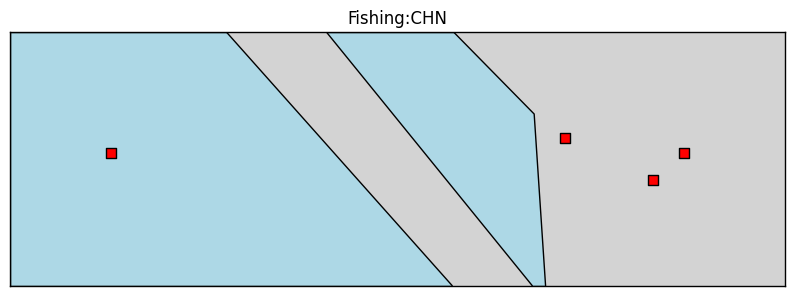

In [100]:
vessel_event_plot(vessels[13])

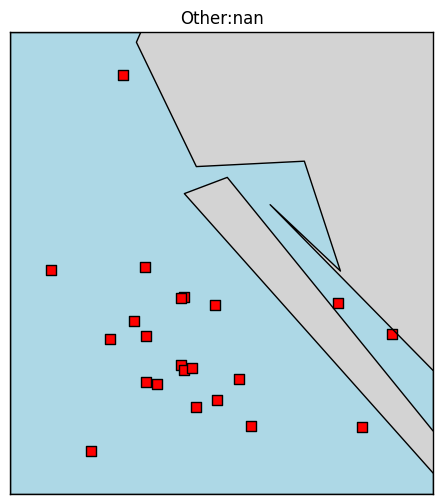

In [101]:
vessel_event_plot(vessels[14])

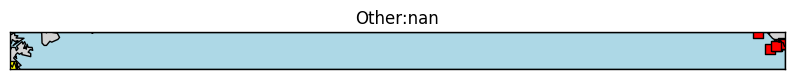

In [102]:
vessel_event_plot(vessels[15])

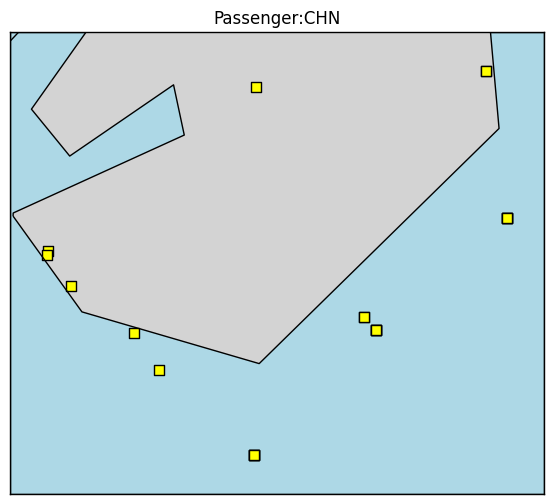

In [103]:
vessel_event_plot(vessels[16])